# Detección de Fraude en Seguros de Automóvil — AutoGuard Seguros
## Trabajo Final ML — Curso 2025-2026

In [1]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    classification_report, confusion_matrix, fbeta_score, make_scorer,
    precision_recall_curve, roc_auc_score, roc_curve, average_precision_score
)
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn import set_config

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from category_encoders import BinaryEncoder, TargetEncoder

warnings.filterwarnings('ignore')
set_config(transform_output="pandas")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("✅ Imports completados")


✅ Imports completados


# 1. Carga y Exploración de Datos

In [2]:
# Cargar el dataset final (ya con target construido)
df = pd.read_csv(r"C:\Users\Miguel Fernández\Desktop\2º CURSO\SEGUNDO SEMESTRE\Aprendizaje Automático\Trabajo_Fraudes\data\df_final.csv")
print(f"Shape: {df.shape}")
print(f"\nDistribución del target:")
print(df['fraud_flag'].value_counts())
print(f"\n% Fraude: {df['fraud_flag'].mean()*100:.2f}%")
df.head()


Shape: (12267, 46)

Distribución del target:
fraud_flag
0    11389
1      878
Name: count, dtype: int64

% Fraude: 7.16%


,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating,fraud_flag
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0,0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0,1
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0,0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0,0


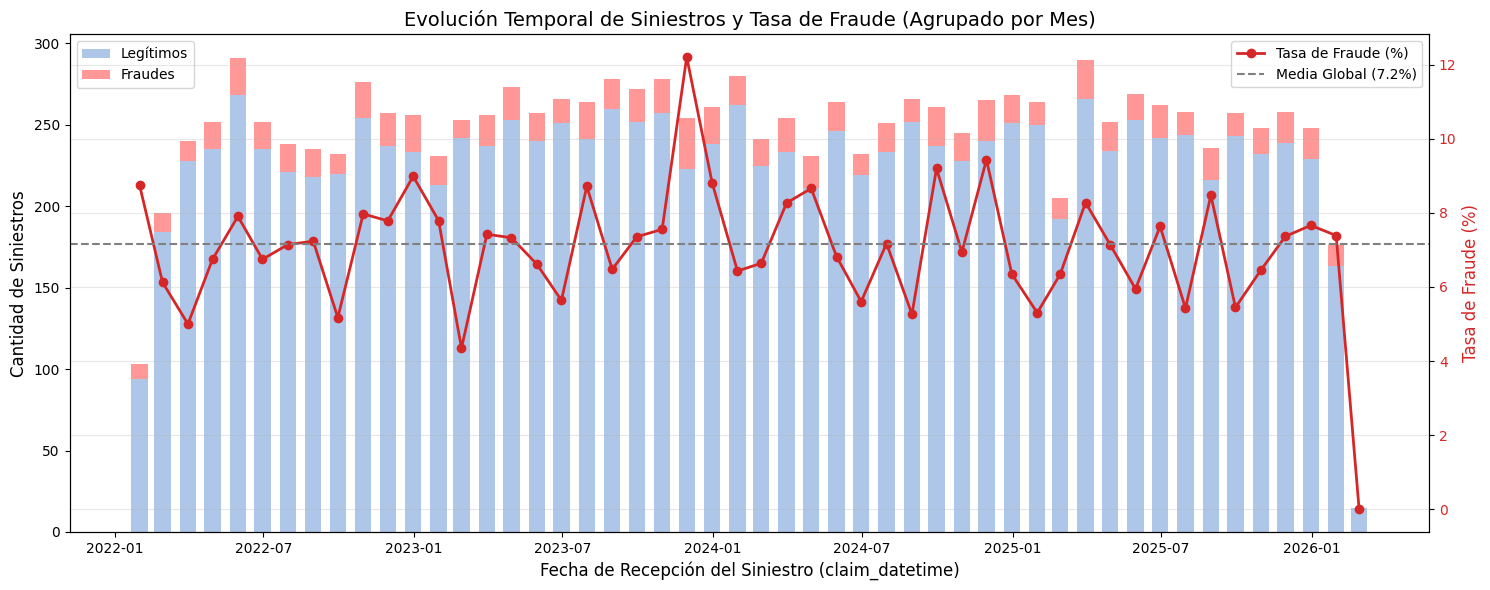

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Asegurar que la columna es formato fecha
df_plot = df.copy() # Usamos una copia para no alterar el dataframe original
df_plot['claim_datetime'] = pd.to_datetime(df_plot['claim_datetime'])

# 2. Agrupar los datos por mes ('ME' = Month End). 
# Si prefieres verlo por semanas, cambia 'ME' por 'W'
monthly_stats = df_plot.set_index('claim_datetime').resample('ME').agg(
    Total_Siniestros=('fraud_flag', 'count'),
    Total_Fraudes=('fraud_flag', 'sum'),
    Tasa_Fraude=('fraud_flag', 'mean')
)

# Calculamos los legítimos para apilar las barras correctamente
monthly_stats['Legitimos'] = monthly_stats['Total_Siniestros'] - monthly_stats['Total_Fraudes']

# 3. Crear el gráfico de doble eje
fig, ax1 = plt.subplots(figsize=(15, 6))

# Eje Y izquierdo: Barras de volumen
ax1.bar(monthly_stats.index, monthly_stats['Legitimos'], width=20, label='Legítimos', color='#aec7e8')
ax1.bar(monthly_stats.index, monthly_stats['Total_Fraudes'], bottom=monthly_stats['Legitimos'], width=20, label='Fraudes', color='#ff9896')
ax1.set_xlabel('Fecha de Recepción del Siniestro (claim_datetime)', fontsize=12)
ax1.set_ylabel('Cantidad de Siniestros', fontsize=12)
ax1.legend(loc='upper left')

# Eje Y derecho: Línea de Tasa de Fraude (%)
ax2 = ax1.twinx()
ax2.plot(monthly_stats.index, monthly_stats['Tasa_Fraude'] * 100, color='#d62728', marker='o', linewidth=2, label='Tasa de Fraude (%)')
ax2.set_ylabel('Tasa de Fraude (%)', color='#d62728', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')

# Añadir línea punteada con la media global de fraude para referencia
media_global = df_plot['fraud_flag'].mean() * 100
ax2.axhline(media_global, color='gray', linestyle='--', label=f'Media Global ({media_global:.1f}%)')
ax2.legend(loc='upper right')

# Formato final
plt.title('Evolución Temporal de Siniestros y Tasa de Fraude (Agrupado por Mes)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
fig.tight_layout()

# Mostrar gráfico
plt.show()

In [4]:
# Info general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12267 entries, 0 to 12266
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   claim_id                  12267 non-null  object 
 1   policy_id                 12267 non-null  object 
 2   customer_id               12267 non-null  object 
 3   vehicle_id                12267 non-null  object 
 4   agent_id                  12267 non-null  object 
 5   accident_datetime         12267 non-null  object 
 6   claim_datetime            12267 non-null  object 
 7   fault                     12267 non-null  object 
 8   accident_area             12267 non-null  object 
 9   accident_description      12267 non-null  object 
 10  accident_latitude         12267 non-null  float64
 11  accident_longitude        12267 non-null  float64
 12  police_report_filed       12267 non-null  object 
 13  witness_present           12267 non-null  object 
 14  number

In [5]:
# Estadísticas descriptivas numéricas
df.describe()


,accident_latitude,accident_longitude,number_of_supplements,claimed_amount_eur,deductible,annual_premium_eur,number_of_cars,postal_code,manufacture_year,purchase_price_eur,odometer_km,driver_rating,fraud_flag
count,12267.000000,12267.000000,12267.000000,12267.000000,12267.000000,12267.000000,12267.000000,12267.000000,9758.000000,9758.000000,9758.000000,9758.000000,12267.000000
mean,39.850914,-2.970615,3.477541,2999.131380,451.389908,752.307359,4.502975,27578.675634,2014.633122,21771.210658,139430.233757,2.178315,0.071574
std,2.252370,3.624874,2.279481,3873.780393,129.657264,400.039304,2.283271,14850.843899,5.798472,14359.113876,79664.252818,0.966898,0.257792
min,36.000737,-9.299434,0.000000,47.330000,300.000000,85.300000,1.000000,1002.000000,2005.000000,2094.690000,506.000000,1.000000,0.000000
25%,37.889615,-6.085252,1.000000,912.225000,400.000000,474.765000,3.000000,14857.000000,2010.000000,12001.700000,69809.000000,1.000000,0.000000
50%,39.833320,-2.989663,3.000000,1822.520000,400.000000,671.370000,4.000000,28187.000000,2015.000000,18010.585000,138015.000000,2.000000,0.000000
75%,41.788675,0.189406,5.000000,3555.105000,500.000000,923.785000,6.000000,40514.000000,2020.000000,27070.080000,208078.500000,3.000000,0.000000
max,43.799790,3.299027,7.000000,82602.400000,700.000000,5000.070000,8.000000,52977.000000,2024.000000,188022.010000,279966.000000,4.000000,1.000000


In [6]:
# Nulos por columna
nulls = df.isnull().sum()
print("Columnas con nulos:")
print(nulls[nulls > 0])


Columnas con nulos:
last_address_change_date    5582
license_plate               2509
make                        2509
model                       2509
manufacture_year            2509
vehicle_category            2509
purchase_price_eur          2509
color                       2509
odometer_km                 2509
driver_rating               2509
dtype: int64


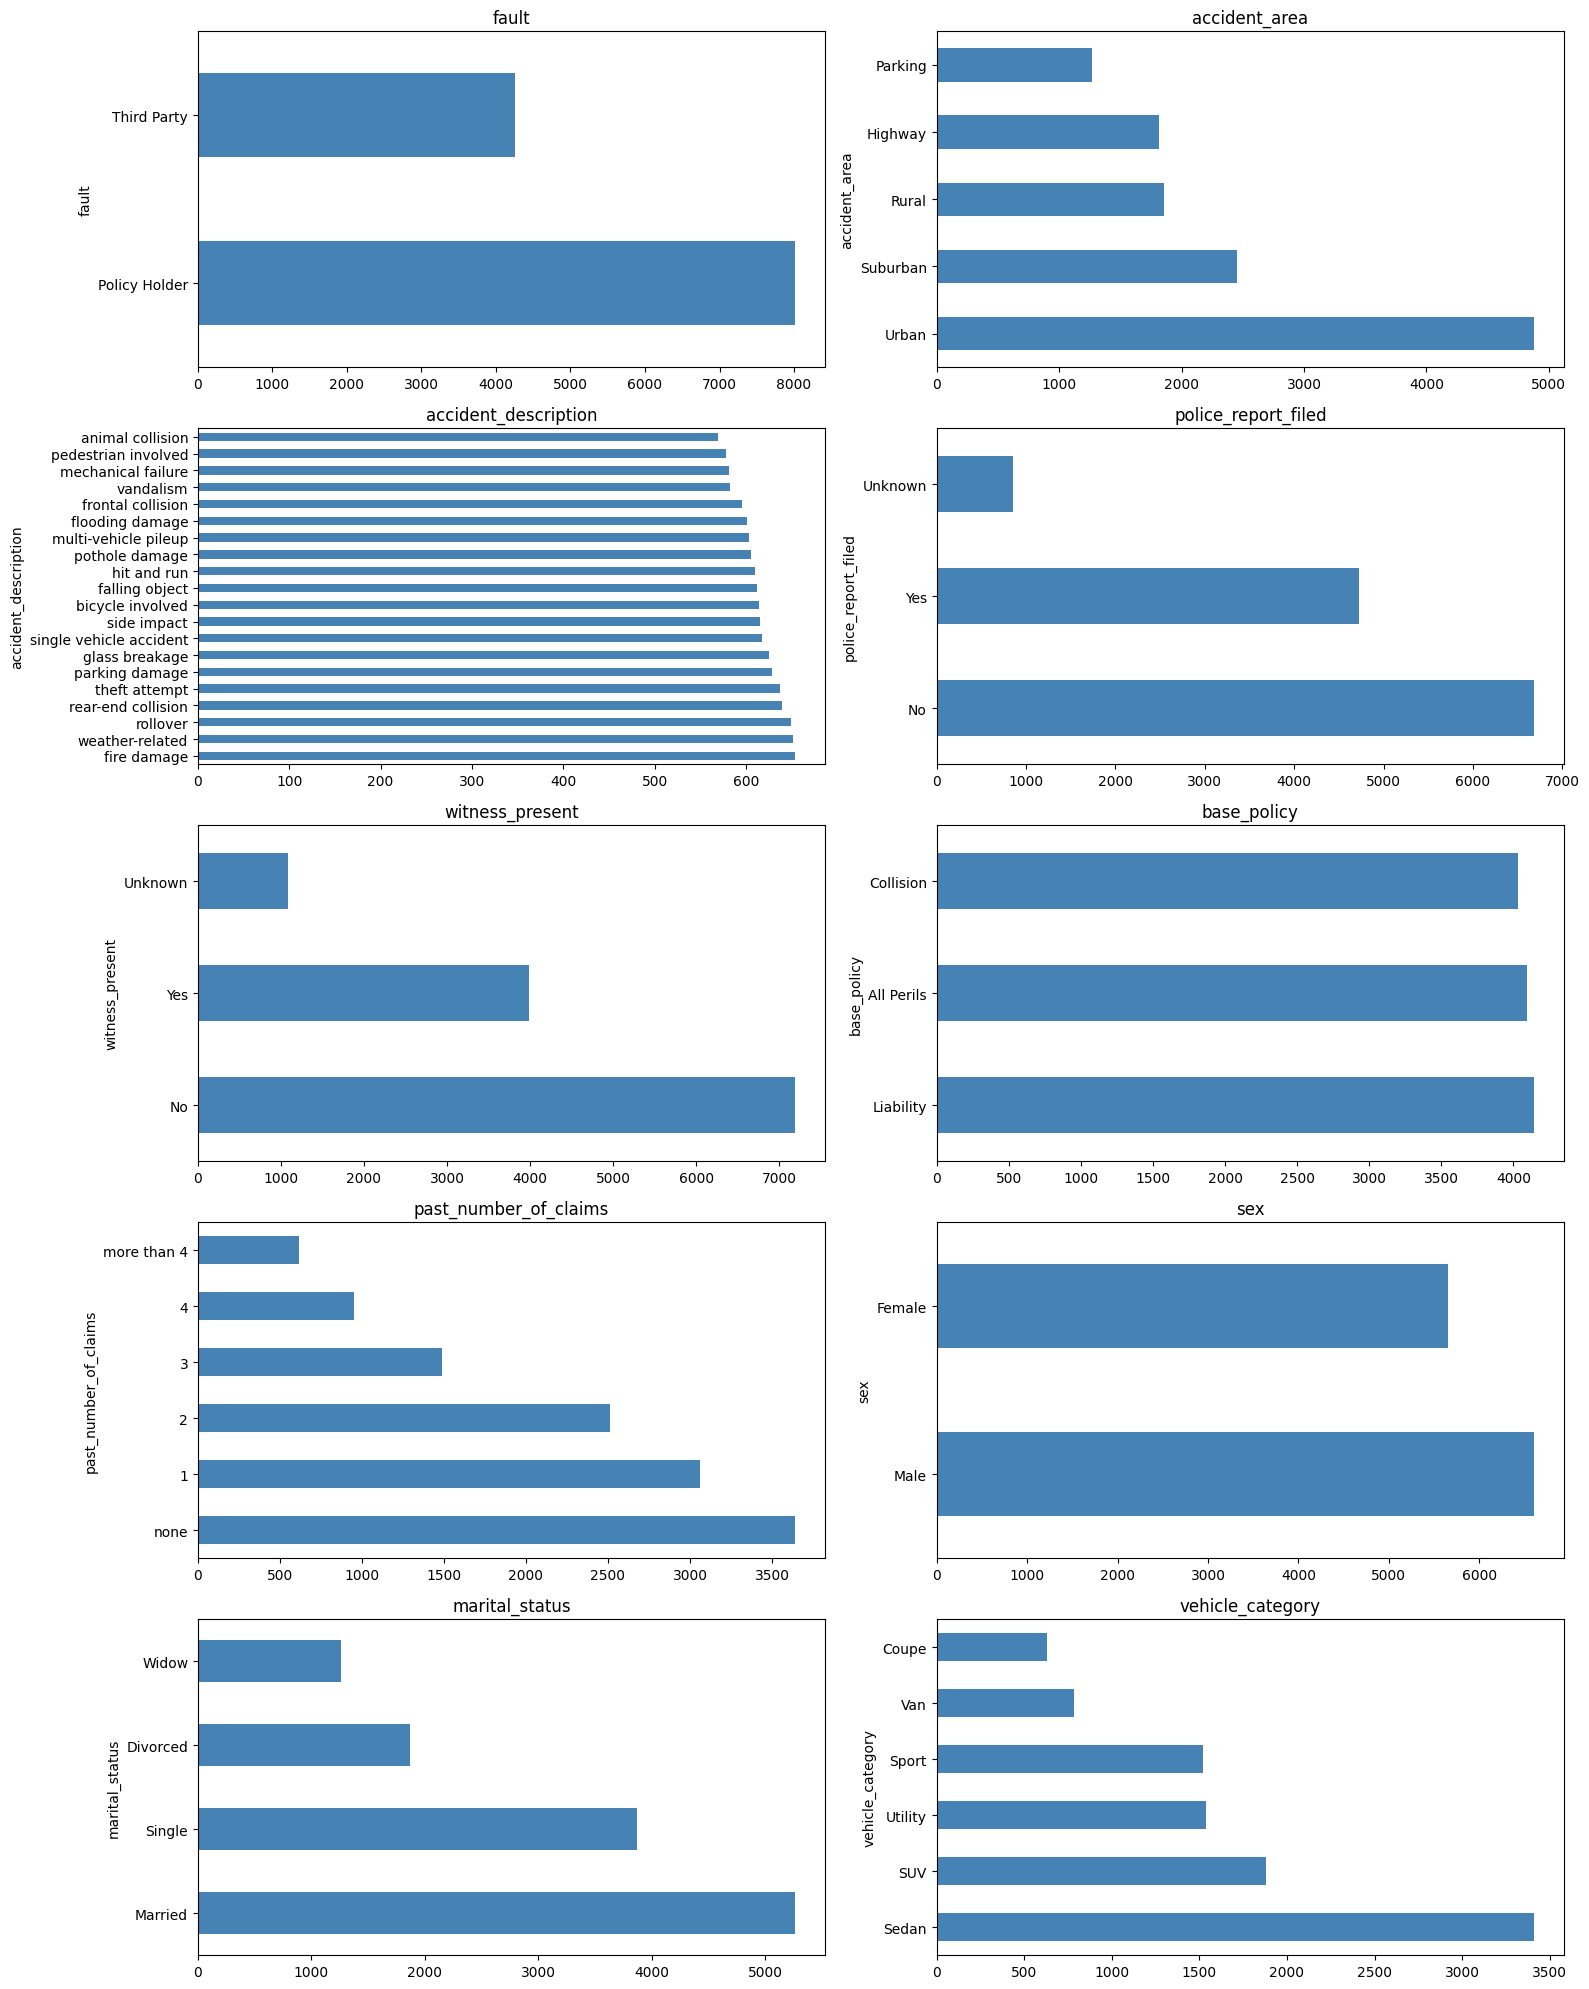

In [7]:
# Distribución de variables categóricas clave
cat_cols_explore = ['fault','accident_area','accident_description','police_report_filed',
                    'witness_present','base_policy','past_number_of_claims','sex',
                    'marital_status','vehicle_category']

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
for ax, col in zip(axes.ravel(), cat_cols_explore):
    df[col].value_counts().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


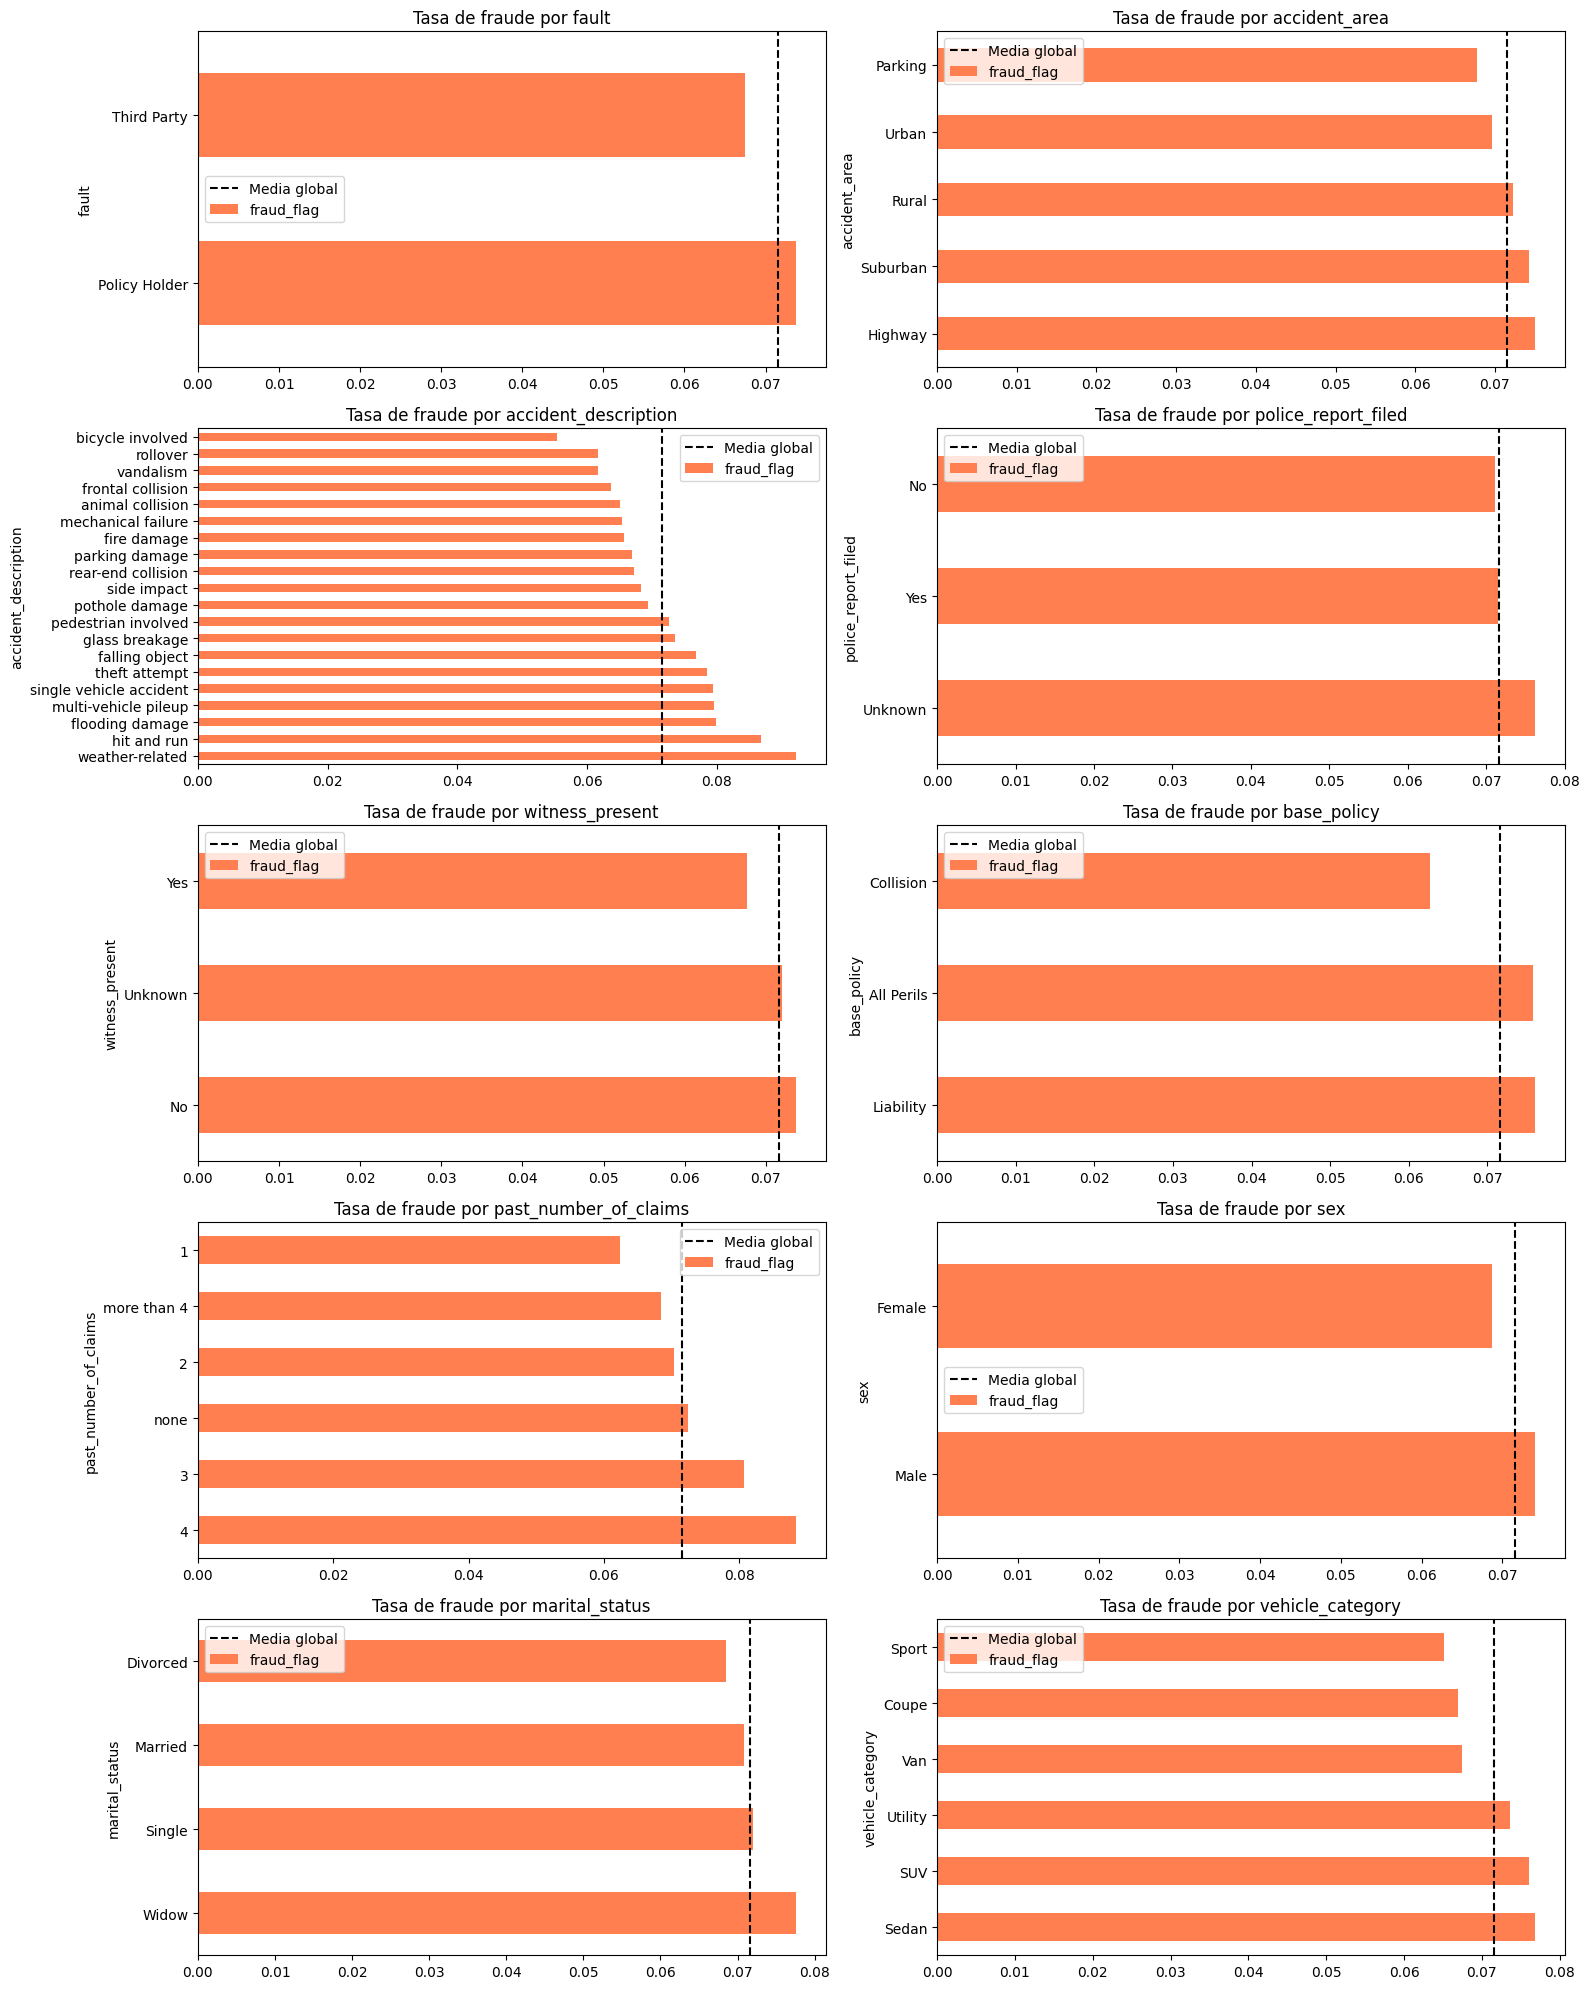

In [8]:
# Tasa de fraude por variables categóricas clave
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
for ax, col in zip(axes.ravel(), cat_cols_explore):
    fraud_rate = df.groupby(col)['fraud_flag'].mean().sort_values(ascending=False)
    fraud_rate.plot(kind='barh', ax=ax, color='coral')
    ax.set_title(f'Tasa de fraude por {col}')
    ax.axvline(x=df['fraud_flag'].mean(), color='black', linestyle='--', label='Media global')
    ax.legend()
plt.tight_layout()
plt.show()


# 2. Feature Engineering

## 2.1 Definición de columnas a usar y a descartar

**Columnas que se descartan:**
- `claim_id`, `policy_id`, `customer_id`, `vehicle_id`: IDs sin valor predictivo directo
- `full_name`, `email`, `phone`, `address`, `license_plate`: datos personales/identificativos
- `repair_workshop`, `model`: alta cardinalidad → ruido
- `agent_id`: se podría usar con target encoding pero lo dejamos para la pipeline avanzada


In [9]:
# Columnas a eliminar siempre (IDs, datos personales, alta cardinalidad)
DROP_COLS = [
    'claim_id', 'policy_id', 'customer_id', 'vehicle_id',
    'full_name', 'email', 'phone', 'address', 'license_plate',
    'repair_workshop', 'model'
]

# Separar target
X = df.drop(columns=['fraud_flag'] + DROP_COLS)
y = df['fraud_flag']

print(f"X shape: {X.shape}")
print(f"Columnas restantes: {list(X.columns)}")


X shape: (12267, 34)
Columnas restantes: ['agent_id', 'accident_datetime', 'claim_datetime', 'fault', 'accident_area', 'accident_description', 'accident_latitude', 'accident_longitude', 'police_report_filed', 'witness_present', 'number_of_supplements', 'claimed_amount_eur', 'policy_type', 'base_policy', 'deductible', 'annual_premium_eur', 'policy_start_date', 'policy_end_date', 'past_number_of_claims', 'number_of_cars', 'sex', 'marital_status', 'date_of_birth', 'city', 'province', 'postal_code', 'last_address_change_date', 'make', 'manufacture_year', 'vehicle_category', 'purchase_price_eur', 'color', 'odometer_km', 'driver_rating']


## 2.2 Transformer personalizado para Feature Engineering

In [10]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Transformer que crea features derivadas a partir del dataframe crudo."""
    
    def __init__(self, advanced=False):
        self.advanced = advanced
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # --- Fechas ---
        for col in ['accident_datetime', 'claim_datetime', 'policy_start_date', 
                     'policy_end_date', 'date_of_birth', 'last_address_change_date']:
            if col in X.columns:
                X[col] = pd.to_datetime(X[col], errors='coerce')
        
        # Días entre accidente y reclamación
        if 'claim_datetime' in X.columns and 'accident_datetime' in X.columns:
            X['days_to_claim'] = (X['claim_datetime'] - X['accident_datetime']).dt.days
        
        # Hora y día de la semana del accidente
        if 'accident_datetime' in X.columns:
            X['accident_hour'] = X['accident_datetime'].dt.hour
            X['accident_dayofweek'] = X['accident_datetime'].dt.dayofweek
            X['accident_is_weekend'] = (X['accident_dayofweek'] >= 5).astype(int)
            X['accident_is_night'] = ((X['accident_hour'] >= 22) | (X['accident_hour'] <= 5)).astype(int)
        
        # Edad del asegurado
        if 'date_of_birth' in X.columns and 'claim_datetime' in X.columns:
            X['age'] = (X['claim_datetime'] - X['date_of_birth']).dt.days / 365.25
        
        # Antigüedad de la póliza en días
        if 'policy_start_date' in X.columns and 'claim_datetime' in X.columns:
            X['policy_age_days'] = (X['claim_datetime'] - X['policy_start_date']).dt.days
        
        # Duración de la póliza
        if 'policy_end_date' in X.columns and 'policy_start_date' in X.columns:
            X['policy_duration_days'] = (X['policy_end_date'] - X['policy_start_date']).dt.days
        
        # Antigüedad del vehículo
        if 'manufacture_year' in X.columns and 'claim_datetime' in X.columns:
            X['vehicle_age'] = X['claim_datetime'].dt.year - X['manufacture_year']
        
        # Ratio claimed_amount / annual_premium
        if 'claimed_amount_eur' in X.columns and 'annual_premium_eur' in X.columns:
            X['claim_premium_ratio'] = X['claimed_amount_eur'] / (X['annual_premium_eur'] + 1)
        
        # Ratio claimed_amount / purchase_price
        if 'claimed_amount_eur' in X.columns and 'purchase_price_eur' in X.columns:
            X['claim_price_ratio'] = X['claimed_amount_eur'] / (X['purchase_price_eur'] + 1)
        
        # Ratio odometer / vehicle_age
        if 'odometer_km' in X.columns:
            vehicle_age_safe = X.get('vehicle_age', pd.Series(1, index=X.index)).replace(0, 1)
            X['km_per_year'] = X['odometer_km'] / vehicle_age_safe
        
        # past_number_of_claims a numérico
        if 'past_number_of_claims' in X.columns:
            claim_map = {'none': 0, '1': 1, '2': 2, '3': 3, '4': 4, 'more than 4': 5}
            X['past_claims_num'] = X['past_number_of_claims'].map(claim_map).fillna(0).astype(int)
        
        if self.advanced:
            # Ratio claimed_amount / deductible
            if 'claimed_amount_eur' in X.columns and 'deductible' in X.columns:
                X['claim_deductible_ratio'] = X['claimed_amount_eur'] / (X['deductible'] + 1)
            
            # Interacción: fault + police_report  
            if 'fault' in X.columns and 'police_report_filed' in X.columns:
                X['fault_no_police'] = ((X['fault'] == 'Policy Holder') & 
                                        (X['police_report_filed'] == 'No')).astype(int)
            
            # Interacción: noche + fin de semana
            if 'accident_is_night' in X.columns and 'accident_is_weekend' in X.columns:
                X['night_weekend'] = X['accident_is_night'] * X['accident_is_weekend']
            
            # Claimed amount alto (por encima del p90)
            if 'claimed_amount_eur' in X.columns:
                X['high_claim'] = (X['claimed_amount_eur'] > X['claimed_amount_eur'].quantile(0.9)).astype(int)
        
        # Eliminar columnas de fecha originales (ya extraída la info)
        date_cols = ['accident_datetime', 'claim_datetime', 'policy_start_date', 
                     'policy_end_date', 'date_of_birth', 'last_address_change_date']
        X = X.drop(columns=[c for c in date_cols if c in X.columns], errors='ignore')
        
        # Eliminar past_number_of_claims original (reemplazada por past_claims_num)
        X = X.drop(columns=['past_number_of_claims'], errors='ignore')
        
        return X

# Test
fe = FeatureEngineer(advanced=True)
X_test_fe = fe.transform(X.head(5))
print(f"Columnas después de FE: {X_test_fe.shape[1]}")
print(list(X_test_fe.columns))


Columnas después de FE: 44
['agent_id', 'fault', 'accident_area', 'accident_description', 'accident_latitude', 'accident_longitude', 'police_report_filed', 'witness_present', 'number_of_supplements', 'claimed_amount_eur', 'policy_type', 'base_policy', 'deductible', 'annual_premium_eur', 'number_of_cars', 'sex', 'marital_status', 'city', 'province', 'postal_code', 'make', 'manufacture_year', 'vehicle_category', 'purchase_price_eur', 'color', 'odometer_km', 'driver_rating', 'days_to_claim', 'accident_hour', 'accident_dayofweek', 'accident_is_weekend', 'accident_is_night', 'age', 'policy_age_days', 'policy_duration_days', 'vehicle_age', 'claim_premium_ratio', 'claim_price_ratio', 'km_per_year', 'past_claims_num', 'claim_deductible_ratio', 'fault_no_police', 'night_weekend', 'high_claim']


## 2.3 Features basadas en algoritmos no supervisados (Isolation Forest + KMeans)

In [11]:
class UnsupervisedFeatures(BaseEstimator, TransformerMixin):
    """Añade scores de Isolation Forest y cluster IDs de KMeans como features."""
    
    def __init__(self, n_clusters=5, contamination=0.07, random_state=42):
        self.n_clusters = n_clusters
        self.contamination = contamination
        self.random_state = random_state
    
    def fit(self, X, y=None):
        # Seleccionar solo columnas numéricas
        self.numeric_cols_ = X.select_dtypes(include=[np.number]).columns.tolist()
        X_num = X[self.numeric_cols_].fillna(0)
        
        # Escalar para Isolation Forest y KMeans
        from sklearn.preprocessing import StandardScaler
        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X_num)
        
        # Isolation Forest
        self.iforest_ = IsolationForest(
            contamination=self.contamination,
            random_state=self.random_state,
            n_estimators=200,
            n_jobs=-1
        )
        self.iforest_.fit(X_scaled)
        
        # KMeans
        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=10
        )
        self.kmeans_.fit(X_scaled)
        
        return self
    
    def transform(self, X):
        X = X.copy()
        X_num = X[self.numeric_cols_].fillna(0)
        X_scaled = self.scaler_.transform(X_num)
        
        # Anomaly score (más negativo = más anómalo)
        X['anomaly_score'] = self.iforest_.decision_function(X_scaled)
        X['is_anomaly'] = (self.iforest_.predict(X_scaled) == -1).astype(int)
        
        # Cluster assignment
        X['cluster_id'] = self.kmeans_.predict(X_scaled)
        
        # Distancia al centroide del cluster asignado
        distances = self.kmeans_.transform(X_scaled)
        X['cluster_distance'] = distances.min(axis=1)
        
        return X

print("✅ UnsupervisedFeatures definido")


✅ UnsupervisedFeatures definido


# 3. Train / Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test fraud rate:  {y_test.mean()*100:.2f}%")


Train: (9813, 34), Test: (2454, 34)
Train fraud rate: 7.15%
Test fraud rate:  7.17%


# 4. Pipeline Baseline — Logistic Regression (sin Feature Engineering)

Pipeline sencilla:
1. Imputar nulos (mediana para numéricos, constante 'missing' para categóricos)
2. Escalar numéricos con StandardScaler
3. OneHotEncoder para categóricos
4. Logistic Regression con class_weight='balanced'


In [13]:
# Identificar columnas por tipo (sobre X_train, sin FE)
# Primero quitamos columnas de fecha y past_number_of_claims que necesitan procesamiento especial
date_cols_baseline = ['accident_datetime', 'claim_datetime', 'policy_start_date', 
                      'policy_end_date', 'date_of_birth', 'last_address_change_date']

X_train_baseline = X_train.drop(columns=date_cols_baseline + ['past_number_of_claims'], errors='ignore')
X_test_baseline = X_test.drop(columns=date_cols_baseline + ['past_number_of_claims'], errors='ignore')

num_cols_baseline = X_train_baseline.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_baseline = X_train_baseline.select_dtypes(include=['object']).columns.tolist()

# Eliminar columnas de muy alta cardinalidad del baseline
high_card = [c for c in cat_cols_baseline if X_train_baseline[c].nunique() > 50]
cat_cols_baseline = [c for c in cat_cols_baseline if c not in high_card]
num_cols_baseline = [c for c in num_cols_baseline if c not in high_card]
cols_to_drop_baseline = high_card

print(f"Numéricas baseline: {num_cols_baseline}")
print(f"Categóricas baseline: {cat_cols_baseline}")
print(f"Descartadas (alta cardinalidad): {cols_to_drop_baseline}")


Numéricas baseline: ['accident_latitude', 'accident_longitude', 'number_of_supplements', 'claimed_amount_eur', 'deductible', 'annual_premium_eur', 'number_of_cars', 'postal_code', 'manufacture_year', 'purchase_price_eur', 'odometer_km', 'driver_rating']
Categóricas baseline: ['fault', 'accident_area', 'accident_description', 'police_report_filed', 'witness_present', 'policy_type', 'base_policy', 'sex', 'marital_status', 'city', 'province', 'make', 'vehicle_category', 'color']
Descartadas (alta cardinalidad): ['agent_id']


In [14]:
# Preprocessor baseline
preprocessor_baseline = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_baseline),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), cat_cols_baseline)
    ],
    remainder='drop'
)

# Pipeline baseline
pipe_baseline = ImbPipeline([
    ('preprocessor', preprocessor_baseline),
    ('variance', VarianceThreshold()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

print("✅ Pipeline baseline definida")
print(pipe_baseline)


✅ Pipeline baseline definida
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['accident_latitude',
                                                   'accident_longitude',
                                                   'number_of_supplements',
                                                   'claimed_amount_eur',
                                                   'deductible',
                                                   'annual_premium_eur',
                                                   'number_of_cars',
                                   

In [15]:
# Métrica: F-beta con beta=2.77
# Justificación: beta=2.77 porque el coste de un FN (2680€) es ~7.66x el coste de un FP (350€)
# beta = sqrt(C_FN / C_FP) = sqrt(2680/350) ≈ 2.77
# Esto penaliza mucho más los falsos negativos (fraudes no detectados)

beta = 2.77
fbeta_scorer = make_scorer(fbeta_score, beta=beta)

print(f"Métrica de optimización: F-beta score con beta={beta}")
print(f"Justificación: sqrt(C_FN/C_FP) = sqrt(2680/350) = {np.sqrt(2680/350):.2f}")


Métrica de optimización: F-beta score con beta=2.77
Justificación: sqrt(C_FN/C_FP) = sqrt(2680/350) = 2.77


In [16]:
# Cross-validation baseline
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'fbeta': fbeta_scorer,
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc'
}

print("Entrenando pipeline baseline con CV...")
t0 = time.time()
cv_results_baseline = cross_validate(
    pipe_baseline, X_train_baseline, y_train,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)
print(f"Tiempo: {time.time()-t0:.1f}s")

print(f"\n--- Resultados Baseline (Logistic Regression) ---")
for metric in ['fbeta', 'precision', 'recall', 'roc_auc']:
    train_mean = cv_results_baseline[f'train_{metric}'].mean()
    test_mean = cv_results_baseline[f'test_{metric}'].mean()
    test_std = cv_results_baseline[f'test_{metric}'].std()
    print(f"  {metric:12s} -> Train: {train_mean:.4f}  |  Test: {test_mean:.4f} ± {test_std:.4f}")


Entrenando pipeline baseline con CV...
Tiempo: 3.4s

--- Resultados Baseline (Logistic Regression) ---
  fbeta        -> Train: 0.3807  |  Test: 0.2733 ± 0.0330
  precision    -> Train: 0.1024  |  Test: 0.0739 ± 0.0092
  recall       -> Train: 0.5894  |  Test: 0.4218 ± 0.0506
  roc_auc      -> Train: 0.6303  |  Test: 0.5030 ± 0.0308


=== Clasificación Baseline (Test set) ===
              precision    recall  f1-score   support

    Legítimo       0.93      0.60      0.73      2278
      Fraude       0.07      0.41      0.12       176

    accuracy                           0.58      2454
   macro avg       0.50      0.50      0.43      2454
weighted avg       0.87      0.58      0.68      2454

F-beta (2.77): 0.2668
AUC-ROC: 0.5088


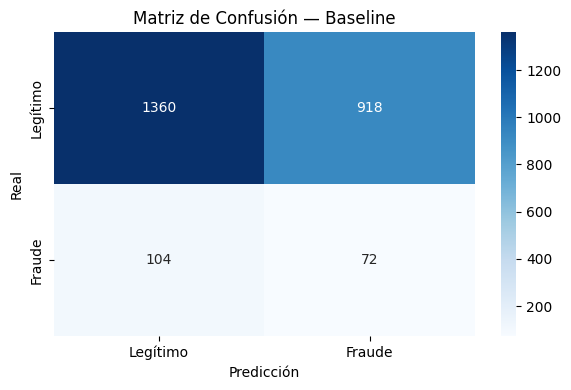

In [17]:
# Entrenar baseline en todo train y evaluar en test
pipe_baseline.fit(X_train_baseline, y_train)
y_pred_baseline = pipe_baseline.predict(X_test_baseline)
y_proba_baseline = pipe_baseline.predict_proba(X_test_baseline)[:, 1]

print("=== Clasificación Baseline (Test set) ===")
print(classification_report(y_test, y_pred_baseline, target_names=['Legítimo', 'Fraude']))
print(f"F-beta ({beta}): {fbeta_score(y_test, y_pred_baseline, beta=beta):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_baseline):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_baseline)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legítimo', 'Fraude'], yticklabels=['Legítimo', 'Fraude'], ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Baseline')
plt.tight_layout()
plt.show()


# 5. Pipeline Avanzada — Con Feature Engineering y Algoritmos No Supervisados

## 5.1 Definición de columnas para la pipeline avanzada

Después del Feature Engineering, las columnas de fecha se convierten en features numéricas 
y se identifican las categóricas restantes.


In [18]:
# Aplicar Feature Engineering para identificar columnas
fe_advanced = FeatureEngineer(advanced=True)
X_train_fe = fe_advanced.transform(X_train)

num_cols_adv = X_train_fe.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_adv = X_train_fe.select_dtypes(include=['object']).columns.tolist()

# Eliminar alta cardinalidad de categóricas
high_card_adv = [c for c in cat_cols_adv if X_train_fe[c].nunique() > 50]
cat_cols_adv = [c for c in cat_cols_adv if c not in high_card_adv]

print(f"Numéricas tras FE: {len(num_cols_adv)} -> {num_cols_adv}")
print(f"Categóricas tras FE: {len(cat_cols_adv)} -> {cat_cols_adv}")
print(f"Descartadas (alta cardinalidad): {high_card_adv}")


Numéricas tras FE: 29 -> ['accident_latitude', 'accident_longitude', 'number_of_supplements', 'claimed_amount_eur', 'deductible', 'annual_premium_eur', 'number_of_cars', 'postal_code', 'manufacture_year', 'purchase_price_eur', 'odometer_km', 'driver_rating', 'days_to_claim', 'accident_hour', 'accident_dayofweek', 'accident_is_weekend', 'accident_is_night', 'age', 'policy_age_days', 'policy_duration_days', 'vehicle_age', 'claim_premium_ratio', 'claim_price_ratio', 'km_per_year', 'past_claims_num', 'claim_deductible_ratio', 'fault_no_police', 'night_weekend', 'high_claim']
Categóricas tras FE: 14 -> ['fault', 'accident_area', 'accident_description', 'police_report_filed', 'witness_present', 'policy_type', 'base_policy', 'sex', 'marital_status', 'city', 'province', 'make', 'vehicle_category', 'color']
Descartadas (alta cardinalidad): ['agent_id']


In [19]:
# Preprocessor avanzado
preprocessor_advanced = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), num_cols_adv),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), cat_cols_adv)
    ],
    remainder='drop'
)

print("✅ Preprocessor avanzado definido")


✅ Preprocessor avanzado definido


## 5.2 Análisis de Importancia de Features (Top 45)

Total features tras preprocesamiento: 185

--- Top 45 Features por Importancia ---
   1. num__annual_premium_eur                       -> 0.0683
   2. num__age                                      -> 0.0580
   3. num__accident_latitude                        -> 0.0546
   4. num__accident_longitude                       -> 0.0482
   5. num__policy_age_days                          -> 0.0465
   6. num__postal_code                              -> 0.0464
   7. num__odometer_km                              -> 0.0443
   8. num__km_per_year                              -> 0.0421
   9. num__claim_premium_ratio                      -> 0.0416
  10. num__claim_deductible_ratio                   -> 0.0387
  11. num__purchase_price_eur                       -> 0.0358
  12. num__claimed_amount_eur                       -> 0.0347
  13. num__claim_price_ratio                        -> 0.0333
  14. num__accident_hour                            -> 0.0253
  15. num__days_to_claim                         

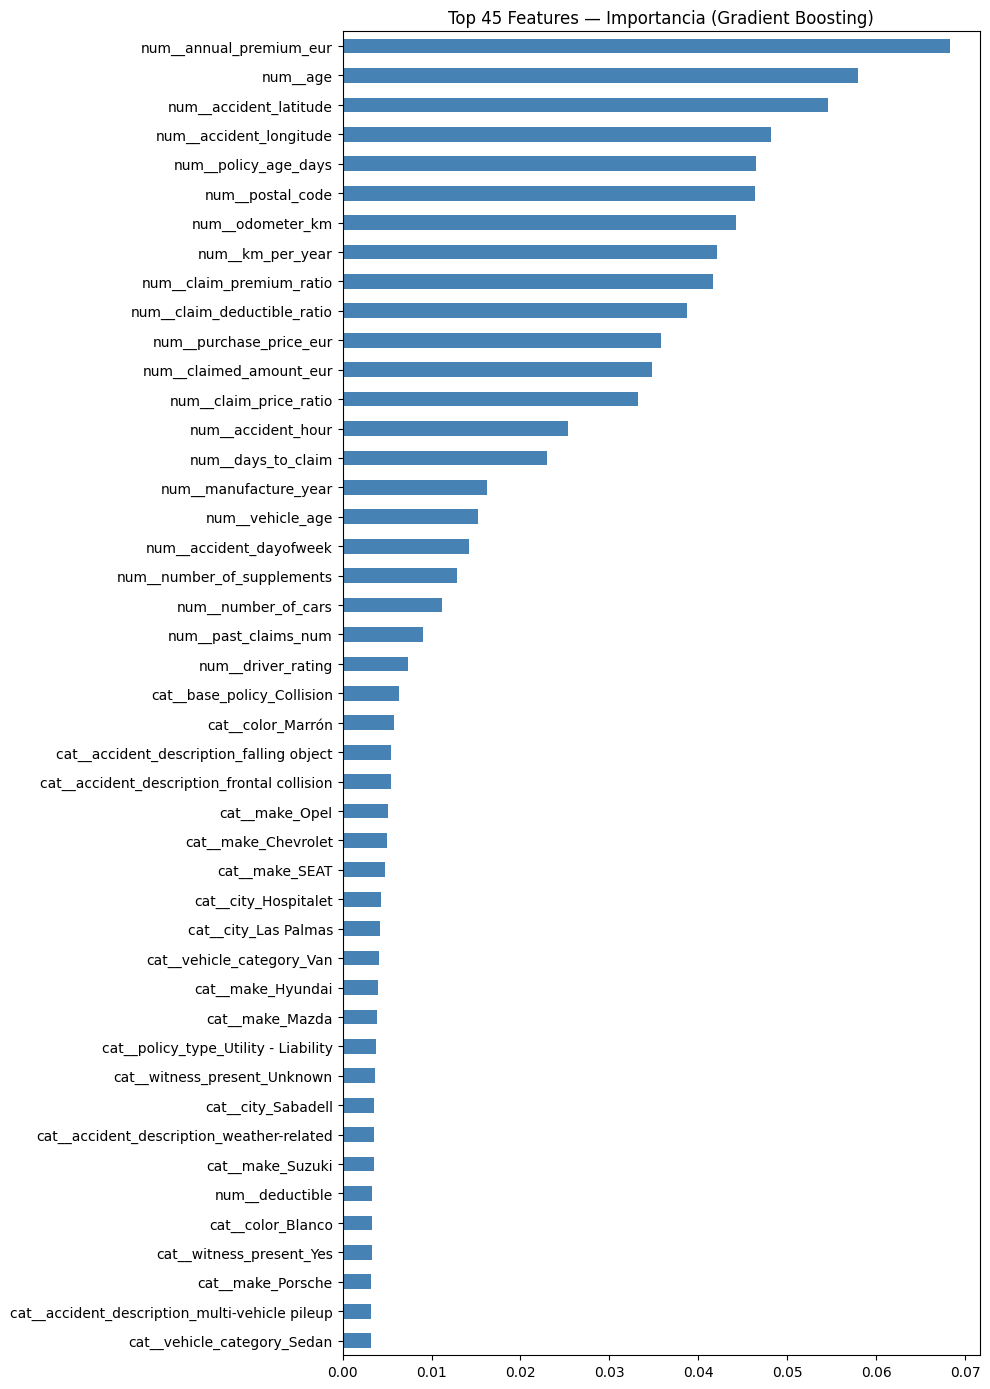

In [20]:
# Entrenar un modelo rápido para ver importancia de features
from sklearn.ensemble import GradientBoostingClassifier

# Preprocesar datos
X_train_fe = fe_advanced.transform(X_train)
X_train_processed = preprocessor_advanced.fit_transform(X_train_fe)

# Obtener nombres de features
feature_names = preprocessor_advanced.get_feature_names_out()
print(f"Total features tras preprocesamiento: {len(feature_names)}")

# Modelo rápido de importancia
gb_importance = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42, 
    subsample=0.8, learning_rate=0.1
)
gb_importance.fit(X_train_processed, y_train)

# Importancia
importances = pd.Series(gb_importance.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

print(f"\n--- Top 45 Features por Importancia ---")
top45 = importances.head(45)
for i, (feat, imp) in enumerate(top45.items()):
    print(f"  {i+1:2d}. {feat:45s} -> {imp:.4f}")

fig, ax = plt.subplots(figsize=(10, 14))
top45.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 45 Features — Importancia (Gradient Boosting)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [21]:
# Identificar features con importancia ~0 (ruido potencial)
low_importance = importances[importances < 0.001]
print(f"\nFeatures con importancia < 0.001 ({len(low_importance)} features):")
for feat, imp in low_importance.items():
    print(f"  {feat}: {imp:.6f}")

print(f"\n→ Estas features podrían eliminarse para reducir ruido")



Features con importancia < 0.001 (58 features):
  cat__make_Audi: 0.000991
  cat__city_Granada: 0.000987
  cat__accident_description_hit and run: 0.000976
  cat__city_Valencia: 0.000975
  cat__city_Castellón: 0.000966
  cat__police_report_filed_Yes: 0.000957
  cat__fault_Third Party: 0.000941
  cat__vehicle_category_Utility: 0.000916
  cat__make_Kia: 0.000903
  cat__accident_description_fire damage: 0.000843
  cat__province_Guipúzcoa: 0.000815
  cat__province_La Rioja: 0.000752
  cat__color_Rojo: 0.000675
  cat__city_Sevilla: 0.000655
  cat__accident_area_Suburban: 0.000655
  cat__province_Burgos: 0.000647
  cat__accident_description_flooding damage: 0.000643
  cat__make_Land Rover: 0.000608
  num__fault_no_police: 0.000605
  cat__accident_area_Parking: 0.000586
  cat__make_Nissan: 0.000586
  cat__accident_description_rollover: 0.000568
  cat__vehicle_category_missing: 0.000565
  cat__province_Almería: 0.000559
  cat__province_Huelva: 0.000552
  cat__make_BMW: 0.000545
  cat__city_San

# 6. Comparativa de Modelos

## 6.1 Definición de pipelines por modelo

Modelos a comparar:
1. **Logistic Regression** — Baseline mejorado con FE
2. **XGBoost** — Gradient boosting optimizado
3. **LightGBM** — Gradient boosting eficiente
4. **MLPClassifier** — Red neuronal feedforward


In [22]:
# Función para construir pipeline completa
def build_pipeline(classifier, use_unsupervised=True, use_smote=True):
    steps = [
        ('fe', FeatureEngineer(advanced=True)),
        ('preprocessor', preprocessor_advanced),
        ('variance', VarianceThreshold(threshold=0.0)),
    ]
    
    if use_unsupervised:
        steps.append(('unsupervised', UnsupervisedFeatures(n_clusters=5, contamination=0.07)))
    
    if use_smote:
        steps.append(('smote', SMOTE(random_state=42, k_neighbors=5)))
    
    steps.append(('classifier', classifier))
    
    return ImbPipeline(steps)


# Definir modelos
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, C=1.0
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=len(y_train[y_train==0])/max(len(y_train[y_train==1]),1),
        random_state=42, n_jobs=-1, eval_metric='logloss',
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=len(y_train[y_train==0])/max(len(y_train[y_train==1]),1),
        random_state=42, n_jobs=-1, verbose=-1,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0
    ),
    'MLPClassifier': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=42,
        early_stopping=True, validation_fraction=0.15, 
        learning_rate='adaptive', alpha=0.001
    ),
}

# Construir pipelines
pipelines = {}
for name, clf in models.items():
    use_smote = name != 'XGBoost' and name != 'LightGBM'  # XGB y LGBM manejan desbalanceo internamente
    pipelines[name] = build_pipeline(clf, use_unsupervised=True, use_smote=use_smote)

print("✅ Pipelines definidas:")
for name in pipelines:
    print(f"  - {name}")


✅ Pipelines definidas:
  - LogisticRegression
  - XGBoost
  - LightGBM
  - MLPClassifier


In [23]:
# Cross-validation comparativa
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, pipe in pipelines.items():
    print(f"\nEntrenando {name}...")
    t0 = time.time()
    cv_res = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
    )
    elapsed = time.time() - t0
    results[name] = cv_res
    
    print(f"  Tiempo: {elapsed:.1f}s")
    for metric in ['fbeta', 'recall', 'precision', 'roc_auc']:
        test_mean = cv_res[f'test_{metric}'].mean()
        test_std = cv_res[f'test_{metric}'].std()
        print(f"  {metric:12s} -> {test_mean:.4f} ± {test_std:.4f}")



Entrenando LogisticRegression...
  Tiempo: 6.3s
  fbeta        -> 0.2609 ± 0.0264
  recall       -> 0.3975 ± 0.0391
  precision    -> 0.0718 ± 0.0076
  roc_auc      -> 0.4933 ± 0.0261

Entrenando XGBoost...
  Tiempo: 5.0s
  fbeta        -> 0.0215 ± 0.0090
  recall       -> 0.0199 ± 0.0083
  precision    -> 0.0553 ± 0.0265
  roc_auc      -> 0.4849 ± 0.0316

Entrenando LightGBM...
  Tiempo: 5.3s
  fbeta        -> 0.0391 ± 0.0056
  recall       -> 0.0370 ± 0.0054
  precision    -> 0.0686 ± 0.0136
  roc_auc      -> 0.5039 ± 0.0203

Entrenando MLPClassifier...
  Tiempo: 6.2s
  fbeta        -> 0.0517 ± 0.0101
  recall       -> 0.0498 ± 0.0099
  precision    -> 0.0735 ± 0.0119
  roc_auc      -> 0.4913 ± 0.0205


In [24]:
# Tabla resumen de resultados
summary = []
for name, cv_res in results.items():
    row = {'Modelo': name}
    for metric in ['fbeta', 'precision', 'recall', 'roc_auc']:
        row[f'{metric}_mean'] = cv_res[f'test_{metric}'].mean()
        row[f'{metric}_std'] = cv_res[f'test_{metric}'].std()
    summary.append(row)

df_summary = pd.DataFrame(summary).sort_values('fbeta_mean', ascending=False)
print("\n=== Resumen Comparativo (ordenado por F-beta) ===")
df_summary



=== Resumen Comparativo (ordenado por F-beta) ===


,Modelo,fbeta_mean,fbeta_std,precision_mean,precision_std,recall_mean,recall_std,roc_auc_mean,roc_auc_std
0,LogisticRegression,0.260906,0.026405,0.071753,0.007567,0.397497,0.039144,0.493301,0.026134
3,MLPClassifier,0.051724,0.010061,0.073519,0.011930,0.049828,0.009916,0.491316,0.020521
2,LightGBM,0.039070,0.005636,0.068571,0.013643,0.037042,0.005374,0.503926,0.020300
1,XGBoost,0.021513,0.008999,0.055265,0.026508,0.019949,0.008304,0.484850,0.031607


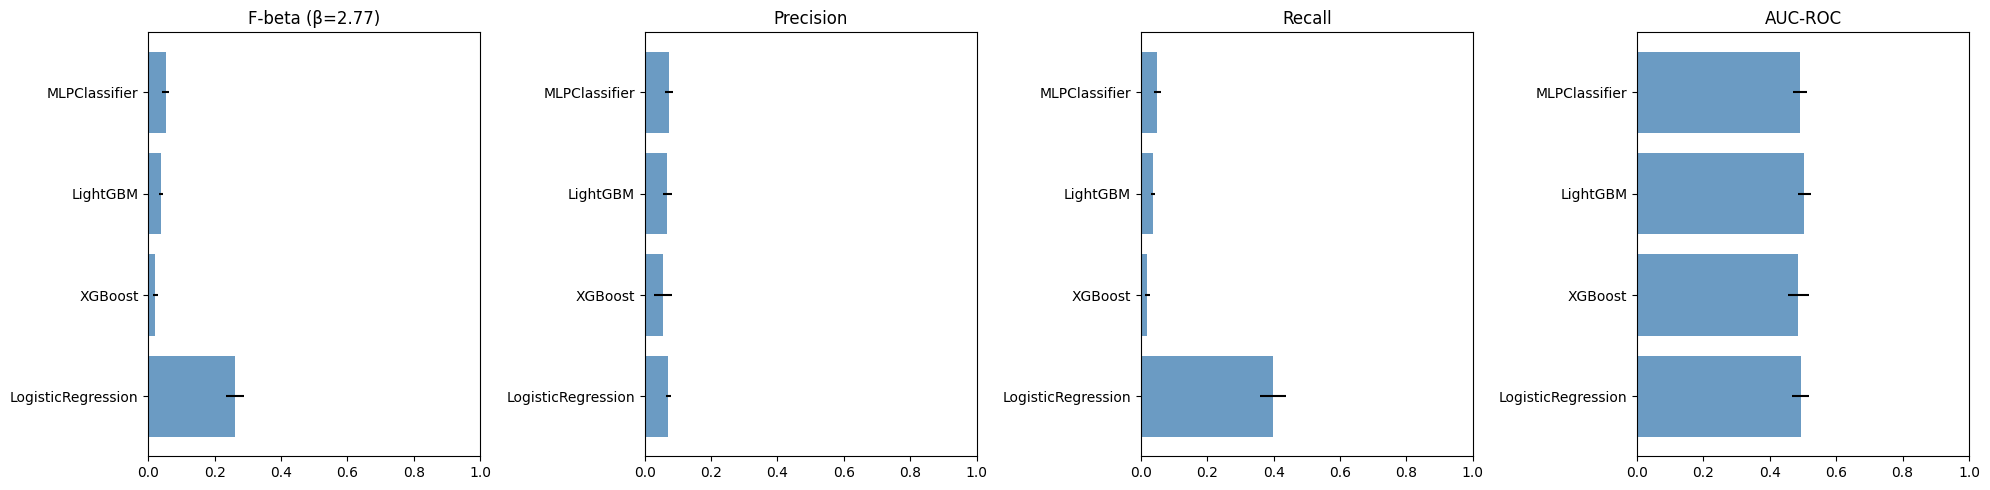

In [25]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics_plot = ['fbeta', 'precision', 'recall', 'roc_auc']
titles = [f'F-beta (β={beta})', 'Precision', 'Recall', 'AUC-ROC']

for ax, metric, title in zip(axes, metrics_plot, titles):
    means = [results[m][f'test_{metric}'].mean() for m in results]
    stds = [results[m][f'test_{metric}'].std() for m in results]
    bars = ax.barh(list(results.keys()), means, xerr=stds, color='steelblue', alpha=0.8)
    ax.set_title(title)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


# 7. Hyperparameter Tuning del Mejor Modelo

In [26]:
# Seleccionar el mejor modelo según F-beta
best_model_name = df_summary.iloc[0]['Modelo']
print(f"Mejor modelo: {best_model_name}")
print(f"Procedemos a hacer tuning de hiperparámetros...")


Mejor modelo: LogisticRegression
Procedemos a hacer tuning de hiperparámetros...


In [27]:
# Grid Search para XGBoost (ajustar si otro modelo es el mejor)
# Si el mejor modelo no es XGBoost, ajustar los parámetros acorde

param_grid_xgb = {
    'classifier__n_estimators': [200, 400, 600],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.7, 0.9],
    'classifier__colsample_bytree': [0.7, 0.9],
}

param_grid_lgbm = {
    'classifier__n_estimators': [200, 400, 600],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__num_leaves': [31, 63],
    'classifier__subsample': [0.7, 0.9],
}

param_grid_lr = {
    'classifier__C': [0.0001,0.001,0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['saga'],
}

param_grid_mlp = {
    'classifier__hidden_layer_sizes': [(64, 32), (128, 64, 32), (256, 128, 64)],
    'classifier__alpha': [0.0001, 0.001, 0.01],
    'classifier__learning_rate': ['adaptive'],
}

# Seleccionar grid según mejor modelo
param_grids = {
    'XGBoost': param_grid_xgb,
    'LightGBM': param_grid_lgbm,
    'LogisticRegression': param_grid_lr,
    'MLPClassifier': param_grid_mlp,
}

best_pipe = pipelines[best_model_name]
param_grid = param_grids.get(best_model_name, {})

print(f"Tuning {best_model_name} con {len(param_grid)} parámetros...")
print(f"Grid: {param_grid}")


Tuning LogisticRegression con 3 parámetros...
Grid: {'classifier__C': [0.0001, 0.001, 0.01, 0.1, 1, 10], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['saga']}


In [ ]:
import optuna
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import fbeta_score
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import VarianceThreshold

# ==========================================
# 1. PREPARACIÓN: ORDEN CRONOLÓGICO
# ==========================================
# Es vital que los datos estén ordenados por tiempo antes de usar TimeSeriesSplit
if 'claim_datetime' in X_train.columns:
    X_train['claim_datetime'] = pd.to_datetime(X_train['claim_datetime'])
    X_train = X_train.sort_values('claim_datetime')
    y_train = y_train.loc[X_train.index]
    print("✅ Datos de entrenamiento ordenados cronológicamente.")
else:
    print("⚠️ ADVERTENCIA: Asegúrate de que X_train e y_train estén ordenados cronológicamente.")

# ==========================================
# 2. DEFINICIÓN DE LA BÚSQUEDA (OPTUNA)
# ==========================================
# Objetivo: maximizar F-beta con beta=3.78 (alineado con costes)
beta_optuna = 3.78
min_recall_obj = 0.20
penalty_weight = 0.80

ratio = len(y_train[y_train == 0]) / max(len(y_train[y_train == 1]), 1)
print(f"Ratio clases train (neg/pos): {ratio:.2f}")

def objective(trial):
    # Espacio de búsqueda ajustado para evitar configuraciones degeneradas
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 900, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_child_weight': trial.suggest_int('min_child_weight', 4, 20),
        'gamma': trial.suggest_float('gamma', 1e-6, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', ratio * 0.6, ratio * 1.8),
        'max_delta_step': trial.suggest_int('max_delta_step', 1, 8),
        'tree_method': 'hist',
        'n_jobs': -1,
    }

    # Evitar pasar duplicados explícitos en el constructor
    params.pop('n_jobs', None)
    params.pop('random_state', None)

    clf = XGBClassifier(
        **params,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )

    pipe = ImbPipeline([
        ('fe', FeatureEngineer(advanced=True)),
        ('preprocessor', preprocessor_advanced),
        ('variance', VarianceThreshold(threshold=0.0)),
        ('classifier', clf)
    ])

    tscv = TimeSeriesSplit(n_splits=5)
    fold_scores = []

    for fold_i, (train_idx, valid_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr = X_train.iloc[train_idx]
        X_va = X_train.iloc[valid_idx]
        y_tr = y_train.iloc[train_idx]
        y_va = y_train.iloc[valid_idx]

        pipe.fit(X_tr, y_tr)
        y_proba_va = pipe.predict_proba(X_va)[:, 1]
        # Threshold fijo en 0.5: Optuna solo ajusta el modelo, no la decisión final
        y_pred_va = (y_proba_va >= 0.5).astype(int)

        fb = fbeta_score(y_va, y_pred_va, beta=beta_optuna, zero_division=0)
        rec = ((y_va == 1) & (y_pred_va == 1)).sum() / max((y_va == 1).sum(), 1)

        # Penaliza soluciones con recall muy bajo para evitar el caso "todo negativo"
        score_fold = fb - max(0.0, min_recall_obj - rec) * penalty_weight
        fold_scores.append(score_fold)

        trial.report(float(np.mean(fold_scores)), step=fold_i)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

# ==========================================
# 3. EJECUCIÓN DEL ESTUDIO
# ==========================================
print("\nIniciando optimización Bayesiana con Optuna + TimeSeriesSplit para F-beta...")
t0 = time.time()
optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n⏳ Tiempo total de búsqueda: {time.time()-t0:.1f}s")
print(f"🎯 ¡Mejor objetivo (F-beta penalizado) en Time-Series CV!: {study.best_value:.4f}")
print("⚙️ Mejores hiperparámetros:")
for key, value in study.best_params.items():
    print(f"   - {key}: {value}")


✅ Datos de entrenamiento ordenados cronológicamente.
Ratio clases train (neg/pos): 12.98

Iniciando optimización Bayesiana con Optuna + TimeSeriesSplit para F-beta...


Best trial: 42. Best value: 0.4584: 100%|██████████| 50/50 [02:40<00:00,  3.21s/it]  


⏳ Tiempo total de búsqueda: 160.3s
🎯 ¡Mejor objetivo (F-beta penalizado) en Time-Series CV!: 0.4584
⚙️ Mejores hiperparámetros:
   - n_estimators: 200
   - learning_rate: 0.011988598048632415
   - max_depth: 4
   - min_child_weight: 6
   - gamma: 8.58610587100503e-05
   - subsample: 0.8151070235278705
   - colsample_bytree: 0.998452402116096
   - reg_alpha: 0.5871484848506349
   - reg_lambda: 1.9053917102037148
   - scale_pos_weight: 22.123754739812142
   - max_delta_step: 1


# 8. Optimización de Umbral basada en Matriz de Costes

## 8.1 Cálculo del umbral óptimo

Parámetros económicos:
- **C_perito** = 350€ (coste de enviar perito)
- **C_fraude** = 2.680€ (coste de fraude no detectado)
- **R_deteccion** = 2.680€ (recuperación al detectar fraude)

Para cada umbral θ:
- Coste = FP × 175 + FN × 2680 + TP × 175


In [87]:
# Obtener probabilidades del mejor modelo
# Prioridad: Optuna -> fallback a RandomizedSearchCV
if 'study' in globals() and study is not None and hasattr(study, 'best_params'):
    print("Usando hiperparámetros seleccionados por Optuna para optimizar umbral...")

    params_optuna = dict(study.best_params)
    params_optuna.pop('n_jobs', None)
    params_optuna.pop('random_state', None)
    optuna_threshold = params_optuna.pop('threshold', None)

    # Si por cualquier motivo no viene en study.best_params, usamos ratio de clases
    scale_weight = len(y_train[y_train == 0]) / max(len(y_train[y_train == 1]), 1)
    params_optuna.setdefault('scale_pos_weight', scale_weight)

    clf_optuna = XGBClassifier(
        **params_optuna,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )

    best_estimator = ImbPipeline([
        ('fe', FeatureEngineer(advanced=True)),
        ('preprocessor', preprocessor_advanced),
        ('variance', VarianceThreshold(threshold=0.0)),
        ('classifier', clf_optuna)
    ])
    best_estimator.fit(X_train, y_train)
    model_source = "Optuna"
else:
    print("Optuna no disponible; usando modelo de RandomizedSearchCV.")

y_proba_test = best_estimator.predict_proba(X_test)[:, 1]

# Parámetros económicos
C_PERITO = 175
C_FRAUDE = 2680

# Buscar umbral óptimo
thresholds = np.arange(0.01, 0.99, 0.005)
if optuna_threshold is not None:
    thresholds = np.unique(np.append(thresholds, float(optuna_threshold)))
costs = []
savings = []
metrics_by_threshold = []

# Coste base (sin modelo): todos los fraudes pasan desapercibidos
n_fraud_test = y_test.sum()
n_legit_test = len(y_test) - n_fraud_test
cost_base = n_fraud_test * C_FRAUDE

print(f"Modelo usado para umbral: {model_source}")
if optuna_threshold is not None:
    print(f"Umbral sugerido por Optuna (F-beta): {optuna_threshold:.3f}")
print(f"Coste base (sin modelo) en test set: {cost_base:,.0f}€")
print(f"  ({n_fraud_test} fraudes × {C_FRAUDE}€)")

for t in thresholds:
    y_pred_t = (y_proba_test >= t).astype(int)
    tn = ((y_test == 0) & (y_pred_t == 0)).sum()
    fp = ((y_test == 0) & (y_pred_t == 1)).sum()
    fn = ((y_test == 1) & (y_pred_t == 0)).sum()
    tp = ((y_test == 1) & (y_pred_t == 1)).sum()

    cost = fp * C_PERITO + fn * C_FRAUDE + tp * C_PERITO
    saving = cost_base - cost

    costs.append(cost)
    savings.append(saving)
    metrics_by_threshold.append({
        'threshold': t, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'cost': cost, 'saving': saving,
        'precision': tp/(tp+fp) if (tp+fp) > 0 else 0,
        'recall': tp/(tp+fn) if (tp+fn) > 0 else 0,
        'fbeta': fbeta_score(y_test, y_pred_t, beta=beta)
    })

df_thresh = pd.DataFrame(metrics_by_threshold)

# Umbral óptimo
idx_best = df_thresh['saving'].idxmax()
best_threshold = df_thresh.loc[idx_best, 'threshold']
best_saving = df_thresh.loc[idx_best, 'saving']
best_cost = df_thresh.loc[idx_best, 'cost']

print(f"\n=== UMBRAL ÓPTIMO ===")
print(f"Umbral θ*: {best_threshold:.3f}")
print(f"Coste con modelo: {best_cost:,.0f}€")
print(f"Ahorro neto: {best_saving:,.0f}€ ({best_saving/cost_base*100:.1f}% del coste base)")
print(f"\nDetalle:")
print(f"  TP: {df_thresh.loc[idx_best, 'TP']:.0f}")
print(f"  FP: {df_thresh.loc[idx_best, 'FP']:.0f}")
print(f"  FN: {df_thresh.loc[idx_best, 'FN']:.0f}")
print(f"  TN: {df_thresh.loc[idx_best, 'TN']:.0f}")
print(f"  Precision: {df_thresh.loc[idx_best, 'precision']:.4f}")
print(f"  Recall: {df_thresh.loc[idx_best, 'recall']:.4f}")
print(f"  F-beta: {df_thresh.loc[idx_best, 'fbeta']:.4f}")

Usando hiperparámetros seleccionados por Optuna para optimizar umbral...
Modelo usado para umbral: Optuna
Coste base (sin modelo) en test set: 471,680€
  (176 fraudes × 2680€)

=== UMBRAL ÓPTIMO ===
Umbral θ*: 0.555
Coste con modelo: 422,020€
Ahorro neto: 49,660€ (10.5% del coste base)

Detalle:
  TP: 152
  FP: 1892
  FN: 24
  TN: 386
  Precision: 0.0744
  Recall: 0.8636
  F-beta: 0.3884


Usando hiperparámetros seleccionados por Optuna para optimizar umbral...
Modelo usado para umbral: Optuna
Coste base (sin modelo) en test set: 471,680€
  (176 fraudes × 2680€)

=== UMBRAL ÓPTIMO ===
Umbral θ*: 0.535
Coste con modelo: 416,660€
Ahorro neto: 55,020€ (11.7% del coste base)

Detalle:
  TP: 154
  FP: 1890
  FN: 22
  TN: 388
  Precision: 0.0753
  Recall: 0.8750
  F-beta: 0.3935

Usando hiperparámetros seleccionados por Optuna para optimizar umbral...
Modelo usado para umbral: Optuna
Coste base (sin modelo) en test set: 471,680€
  (176 fraudes × 2680€)

=== UMBRAL ÓPTIMO ===
Umbral θ*: 0.515
Coste con modelo: 413,890€
Ahorro neto: 57,790€ (12.3% del coste base)

Detalle:
  TP: 163
  FP: 2003
  FN: 13
  TN: 275
  Precision: 0.0753
  Recall: 0.9261
  F-beta: 0.4020

Usando hiperparámetros seleccionados por Optuna para optimizar umbral...
Modelo usado para umbral: Optuna
Coste base (sin modelo) en test set: 471,680€
  (176 fraudes × 2680€)

=== UMBRAL ÓPTIMO ===
Umbral θ*: 0.460
Coste con modelo: 418,265€
Ahorro neto: 53,415€ (11.3% del coste base)

Detalle:
  TP: 163
  FP: 2028
  FN: 13
  TN: 250
  Precision: 0.0744
  Recall: 0.9261
  F-beta: 0.3992

Usando hiperparámetros seleccionados por Optuna para optimizar umbral...
Modelo usado para umbral: Optuna
Coste base (sin modelo) en test set: 471,680€
  (176 fraudes × 2680€)

=== UMBRAL ÓPTIMO ===
Umbral θ*: 0.525
Coste con modelo: 426,735€
Ahorro neto: 44,945€ (9.5% del coste base)

Detalle:
  TP: 149
  FP: 1876
  FN: 27
  TN: 402
  Precision: 0.0736
  Recall: 0.8466
  F-beta: 0.3828

Usando hiperparámetros seleccionados por Optuna para optimizar umbral...
Modelo usado para umbral: Optuna
Coste base (sin modelo) en test set: 471,680€
  (176 fraudes × 2680€)

=== UMBRAL ÓPTIMO ===
Umbral θ*: 0.420
Coste con modelo: 419,400€
Ahorro neto: 52,280€ (11.1% del coste base)

Detalle:
  TP: 171
  FP: 2149
  FN: 5
  TN: 129
  Precision: 0.0737
  Recall: 0.9716
  F-beta: 0.4041

Usando hiperparámetros seleccionados por Optuna para optimizar umbral...
Modelo usado para umbral: Optuna
Coste base (sin modelo) en test set: 471,680€
  (176 fraudes × 2680€)

=== UMBRAL ÓPTIMO ===
Umbral θ*: 0.680
Coste con modelo: 467,840€
Ahorro neto: 3,840€ (0.8% del coste base)

Detalle:
  TP: 3
  FP: 9
  FN: 173
  TN: 2269
  Precision: 0.2500
  Recall: 0.0170
  F-beta: 0.0191

# 11. Pipeline Final — Entrenamiento y Exportación

In [30]:
# Entrenar pipeline final con TODOS los datos de entrenamiento
if 'study' in globals() and study is not None and hasattr(study, 'best_params') and study.best_params:
    params_final = dict(study.best_params)
    params_final.pop('n_jobs', None)
    params_final.pop('random_state', None)
    params_final.pop('threshold', None)
    scale_weight = len(y_train[y_train == 0]) / max(len(y_train[y_train == 1]), 1)
    params_final.setdefault('scale_pos_weight', scale_weight)

    clf_final = XGBClassifier(
        **params_final,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
    pipe_final = ImbPipeline([
        ('fe', FeatureEngineer(advanced=True)),
        ('preprocessor', preprocessor_advanced),
        ('variance', VarianceThreshold(threshold=0.0)),
        ('classifier', clf_final)
    ])
    source_final = 'Optuna'
else:
    pipe_final = clone(search.best_estimator_)
    source_final = 'RandomizedSearchCV'

pipe_final.fit(X_train, y_train)

# Verificar en test
y_proba_final = pipe_final.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= best_threshold).astype(int)

print(f"=== Verificación Final en Test Set ({source_final}) ===")
print(classification_report(y_test, y_pred_final, target_names=['Legítimo', 'Fraude']))
print(f"F-beta ({beta}): {fbeta_score(y_test, y_pred_final, beta=beta):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_final):.4f}")

# Cálculo económico final test
tn_f = ((y_test == 0) & (y_pred_final == 0)).sum()
fp_f = ((y_test == 0) & (y_pred_final == 1)).sum()
fn_f = ((y_test == 1) & (y_pred_final == 0)).sum()
tp_f = ((y_test == 1) & (y_pred_final == 1)).sum()

cost_final = fp_f * C_PERITO + fn_f * C_FRAUDE + tp_f * C_PERITO
saving_final = cost_base - cost_final
print(f"\nCoste test sin modelo: {cost_base:,.0f}€")
print(f"Coste test con modelo: {cost_final:,.0f}€")
print(f"Ahorro neto test: {saving_final:,.0f}€ ({saving_final/cost_base*100:.1f}%)")

=== Verificación Final en Test Set (Optuna) ===
              precision    recall  f1-score   support

    Legítimo       0.96      0.06      0.11      2278
      Fraude       0.07      0.97      0.14       176

    accuracy                           0.12      2454
   macro avg       0.52      0.51      0.12      2454
weighted avg       0.90      0.12      0.11      2454

F-beta (2.77): 0.4041
AUC-ROC: 0.5071

Coste test sin modelo: 471,680€
Coste test con modelo: 419,400€
Ahorro neto test: 52,280€ (11.1%)


In [31]:
# RE-ENTRENAR con TODOS los datos (train+test) para el modelo de producción
if 'study' in globals() and study is not None and hasattr(study, 'best_params') and study.best_params:
    params_prod = dict(study.best_params)
    params_prod.pop('n_jobs', None)
    params_prod.pop('random_state', None)
    params_prod.pop('threshold', None)
    scale_weight_full = len(y[y == 0]) / max(len(y[y == 1]), 1)
    params_prod.setdefault('scale_pos_weight', scale_weight_full)

    clf_prod = XGBClassifier(
        **params_prod,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
    pipe_produccion = ImbPipeline([
        ('fe', FeatureEngineer(advanced=True)),
        ('preprocessor', preprocessor_advanced),
        ('variance', VarianceThreshold(threshold=0.0)),
        ('classifier', clf_prod)
    ])
    source_prod = 'Optuna'
else:
    pipe_produccion = clone(search.best_estimator_)
    source_prod = 'RandomizedSearchCV'

pipe_produccion.fit(X, y)

print(f"✅ Pipeline de producción entrenada con todos los datos ({source_prod})")
print(f"Umbral óptimo: {best_threshold:.3f}")

✅ Pipeline de producción entrenada con todos los datos (Optuna)
Umbral óptimo: 0.420


# 12. Predicción sobre Holdout

In [32]:
# Leer holdout (descomentar cuando esté disponible)
# holdout_df = pd.read_csv("holdout.csv")

# X_holdout = holdout_df.drop(columns=['fraud_flag'] + DROP_COLS, errors='ignore')

# y_proba_holdout = pipe_produccion.predict_proba(X_holdout)[:, 1]
# y_pred_holdout = (y_proba_holdout >= best_threshold).astype(int)

# print(f"Predicciones holdout:")
# print(f"  Total: {len(y_pred_holdout)}")
# print(f"  Enviados a perito (pred=1): {y_pred_holdout.sum()}")
# print(f"  No enviados (pred=0): {(y_pred_holdout == 0).sum()}")

# # Si el holdout tiene target:
# # print(classification_report(holdout_df['fraud_flag'], y_pred_holdout))

print("⚠️ Celda preparada para cuando se suba el holdout")


⚠️ Celda preparada para cuando se suba el holdout
